In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.linear_regression import train
from src.preprocessing import preprocess

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### This notebook will use basic linear regression, followed by lasso linear regression, to use as a baseline for comparison with more advanced models

In [2]:
# -- Raw training data
clean_train = preprocess(pd.read_csv("hf://datasets/openadmet/openadmet-expansionrx-challenge-train-data/expansion_data_train_raw.csv"))

# --Defining targets and model/scores dictionaries
targets = []
for col in clean_train.columns:
    if col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
lin_reg_models = {}
lin_reg_scores = {}
lin_reg_data = {}

In [3]:
targets

['LogD', 'KSOL', 'log_HLM CLint', 'log_MLM CLint']

#### Linear Regression

In [4]:
# -- Linear Regression
for target in targets:
    model, scores, X, y = train(clean_train, target)
    lin_reg_models[target] = model
    lin_reg_scores[target] = scores
    lin_reg_data[target] = (X, y)

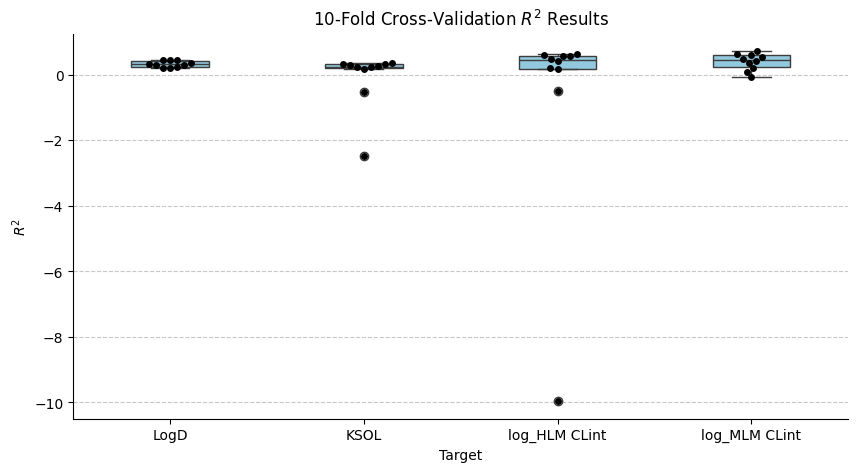

In [5]:
scores_df = pd.DataFrame(lin_reg_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results')
plt.ylabel(r'$R^2$')
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

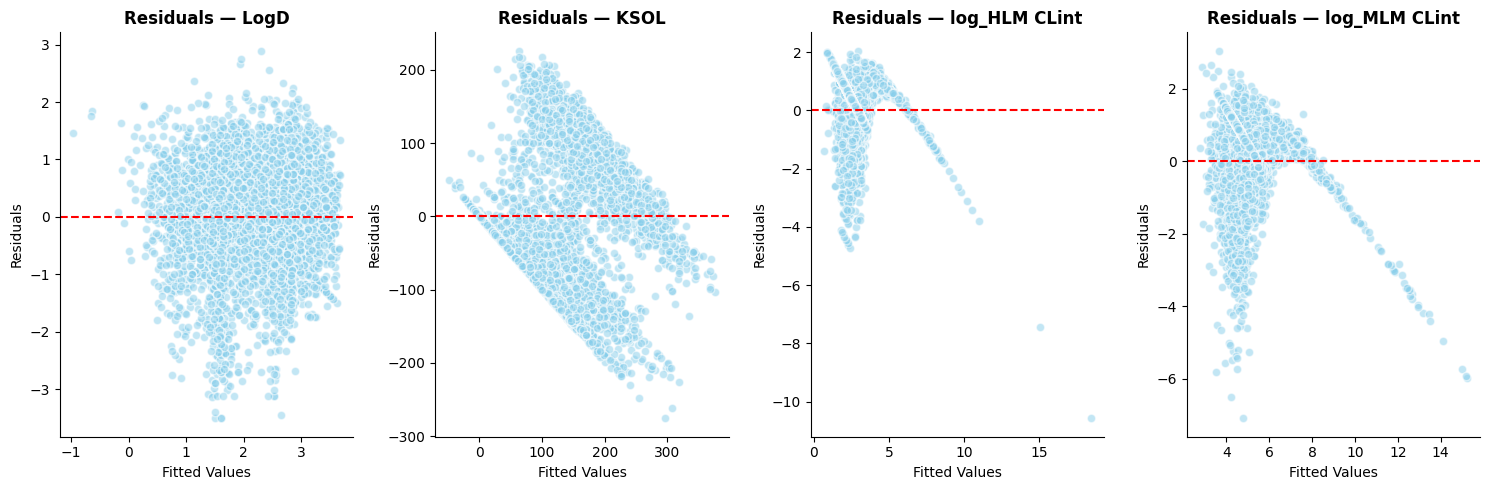

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, lin_reg_models.items()):
    X, y = lin_reg_data[target]
    y_pred = model.predict(X)
    residuals = y - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Basic linear regression residuals show heteroskedasticity, suggesting the models fail to capture non-linear relationships in the data